<header style="background-color: rgb(0, 62, 92); color: white; margin-top: 20px; padding:28px; ">
  <img src="../Images/Xlogo.png" alt="logo" width="115" style="float: left;">
  <p style=" text-align: center; font-size: 30px;">   
   <strong> APM_52448_EP - Deep Learning in Finance   </strong></p>
    <p style=" text-align: center; font-size: 30px;"> 
    <strong> Tutorial 1: Stock Price Forecasting (Deep Learning Refresher) </strong></p>
  <p style=" text-align: left; font-size: 20px;"> Olivier Féron </p>
</header>

**Goal.** Build an end-to-end, *time-aware* forecasting pipeline on daily equity data to experience the challenges of financial prediction and to align on deep learning vocabulary best practices.

**What you'll practice**
- Data retrieval & cleaning
- Proper *time-split* (train / validation / test) and preprocessing
- Baselines (neutral, persistence, linear regression)
- Neural nets (MLP)
- Regularization & early stopping
- Metrics: RMSE/MAE and directional accuracy

> **Important:** Financial series are noisy and difficult to predict. The *lesson* is as important as the numbers you get.


## 0. Setup

- Create/activate your Python environment (conda/venv).

In [1]:
import os, random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Fixing all random starts for reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available()) # Check if GPU card is available


Torch version: 2.10.0+cu128
CUDA available: False


## 1. Data loading, and some basic analysis

In this notebook, data are already downloaded on csv file. But you can also download from yahoo finance by using "yahooquery" package.

csv files have name "ticker.csv" with ticker similar to the one needed to download from yahoo finance: (e.g., `AAPL` for Apple, `AI.PA` for Air Liquidie, `MC.PA` for LVMH).

<span style="color: blue;">**1.1** Download ~10 years of data (from 2014/01/01 to today), keep at least columns `Close` and `Volume`.</span>


In [2]:
# Load data
path = os.path.join("../Data", "AAPL.csv")
df = pd.read_csv(path)

# Delete all rows with a NAN
df = df.dropna().copy()

### 1.1 Basic Sanity Check

Before going further, make sure that the dataset has been correctly loaded.

<span style="color: blue;">**1.2** Display **some basic information** about the `df` Dataframe: </span>
- <span style="color: blue;">**Number of rows and columns**</span>
- <span style="color: blue;">**Head** and **Tail** of the Dataframe (first and lst few rows)</span>
- <span style="color: blue;">**Number of missing values (NaN)** in the Dataset </span>



In [5]:
df["date"] = pd.to_datetime(df["date"])

print(f"{df.shape[0] = } rows and {df.shape[1] = } columns")
print(f"{df.head() = }")
print(f"{df.tail() = }")
print(f"{df.isnull().sum() = }")

df.shape[0] = 6493 rows and df.shape[1] = 10 columns
df.head() =         date symbol      open      high       low     close     volume  \
0 2000-01-03   AAPL  0.936384  1.004464  0.907924  0.999442  535796800   
1 2000-01-04   AAPL  0.966518  0.987723  0.903460  0.915179  512377600   
2 2000-01-05   AAPL  0.926339  0.987165  0.919643  0.928571  778321600   
3 2000-01-06   AAPL  0.947545  0.955357  0.848214  0.848214  767972800   
4 2000-01-07   AAPL  0.861607  0.901786  0.852679  0.888393  460734400   

   adjclose  dividends  splits  
0  0.840094        0.0     0.0  
1  0.769266        0.0     0.0  
2  0.780523        0.0     0.0  
3  0.712977        0.0     0.0  
4  0.746750        0.0     0.0  
df.tail() =            date symbol        open        high         low       close  \
6488 2025-10-20   AAPL  255.889999  264.380005  255.630005  262.239990   
6489 2025-10-21   AAPL  261.880005  265.290009  261.829987  262.769989   
6490 2025-10-22   AAPL  262.649994  262.850006  255.429993

### 1.2 Basic Analysis

The first (and simplest) analysis when we have time series is to plot the data

<span style="color: blue;">**1.3** Plot the **close** price as a time series, and its histogram </span>

When working with financial time series, we almost always prefer to manipulate returns rather than raw prices, because returns have mathematical and statistical properties that make them far more suitable for modeling, comparison, and risk analysis. In particular, returns are more likely to be "stationary" than prices. 

<span style="color: blue;">**1.4** Compute the log returns $y_t = \log(P_t) - \log(P_{t-1})$ </span>

<span style="color: blue;">**1.5** Plot the resulting log returns as a time series, and its histogram </span>

<span style="color: blue;">**1.6** Compare the histogram with the Gaussian probability density function of same mean and std </span>

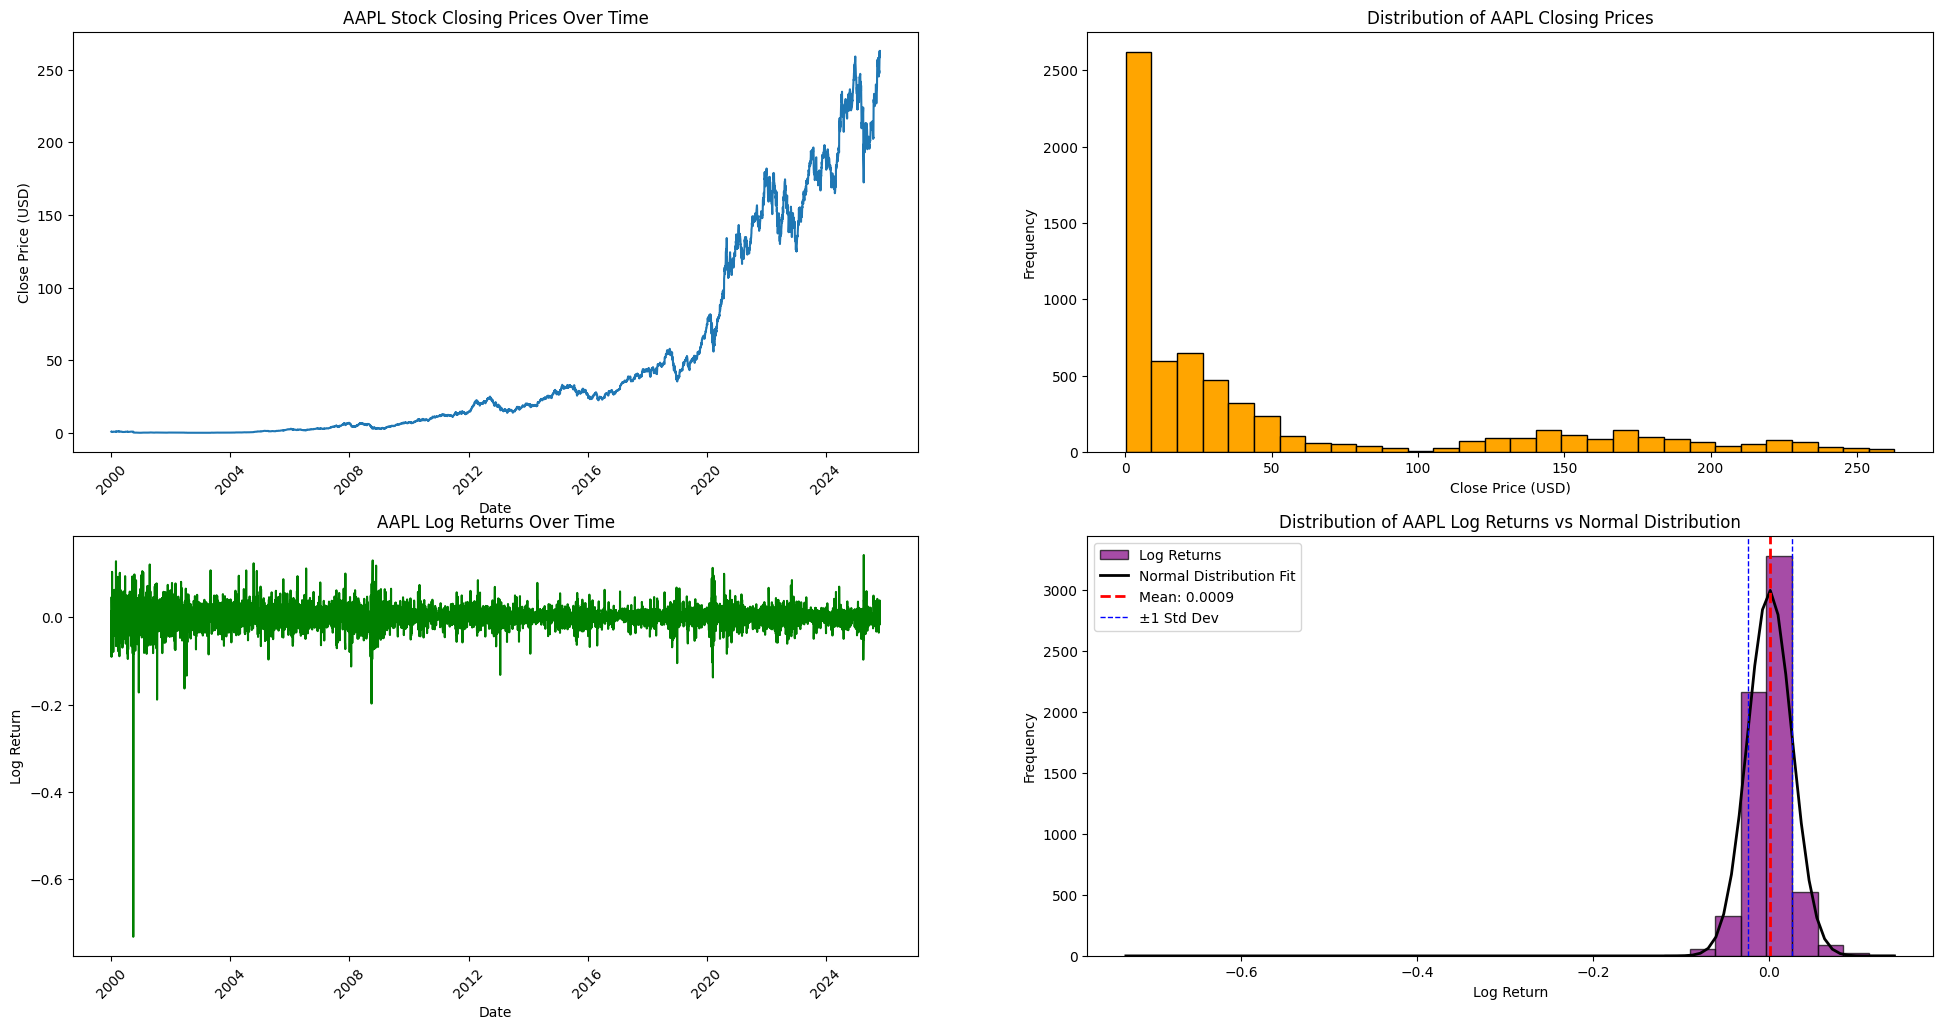

In [14]:
plt.figure(figsize=(24, 12))

plt.subplot(2, 2, 1)
plt.plot(df['date'], df['close'], label='AAPL Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.title('AAPL Stock Closing Prices Over Time')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
plt.hist(df['close'], bins=30, color='orange', edgecolor='black')
plt.xlabel('Close Price (USD)')
plt.ylabel('Frequency')
plt.title('Distribution of AAPL Closing Prices')

log_returns: np.ndarray = np.log(df['close'] / df['close'].shift(1))  # type: ignore 

plt.subplot(2, 2, 3)
plt.plot(df['date'], log_returns, label='Log Returns', color='green')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.title('AAPL Log Returns Over Time')
plt.xticks(rotation=45)

mean_return = log_returns.mean()
std_return = log_returns.std()
plt.subplot(2, 2, 4)
plt.hist(log_returns, bins=30, color='purple', edgecolor='black', alpha=0.7, label='Log Returns')
x_range = np.linspace(log_returns.min(), log_returns.max(), 100)
plt.plot(x_range, len(log_returns) * (log_returns.max() - log_returns.min()) / 30 * (1 / (std_return * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_range - mean_return) / std_return)**2), 'k-', linewidth=2, label='Normal Distribution Fit')
plt.axvline(mean_return, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_return:.4f}')
plt.axvline(mean_return + std_return, color='blue', linestyle='dashed', linewidth=1, label=f'±1 Std Dev')
plt.axvline(mean_return - std_return, color='blue', linestyle='dashed', linewidth=1)
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.title('Distribution of AAPL Log Returns vs Normal Distribution')
plt.legend()

plt.show()


## 2. Targets & features: Data preparation

We want to predict the **next-day log-return**, based on the observation of its historical realization (asssuming stationarity...).

The first objective is to create an appropriate Dataframe ready to use prediction tools. We then define the **target** $y_t$ as the element we want to predict, and the **features** $x_t$ as the explanotory variables used to predict $y_{t+1}$. We then must create a Dataframe where, on each line, there will be the features $x_t$ used and the realized target $y_{t+1}$: 
Ex. of Dataframe (one row):
| $x^1_t$ | $x^2_t$ |$\dots$ | $x^k_t$ | $y_{t+1}$ |

- Target $y_t = \log(P_t) - \log(P_{t-1})$, shifted so that **features at time t** predict **return at t+1**.
- Features: a rolling window of last $k$ log-returns (and optionally simple indicators): $x^i_t = y_{t-i+1}$.

<span style="color: blue;">**2.1** Create the column "target" corresponding, at time $t$, to $y_{t+1}$. </span>

**Pay attention on time and line consistency**: here we want to build a dataframe such that on each line, we have the features and the target we want to predict.

In [25]:
df["target"] = log_returns.shift(-1)  # type: ignore
df["ret"] = log_returns  # type: ignore
df.tail()

,date,symbol,open,high,low,close,volume,adjclose,dividends,splits,ret,target
6488,2025-10-20,AAPL,255.889999,264.380005,255.630005,262.239990,90483000,262.239990,0.0,0.0,0.038681,0.002019
6489,2025-10-21,AAPL,261.880005,265.290009,261.829987,262.769989,46695900,262.769989,0.0,0.0,0.002019,-0.016577
6490,2025-10-22,AAPL,262.649994,262.850006,255.429993,258.450012,45015300,258.450012,0.0,0.0,-0.016577,0.004363
6491,2025-10-23,AAPL,259.940002,260.619995,258.010010,259.579987,32754900,259.579987,0.0,0.0,0.004363,0.012405
6492,2025-10-24,AAPL,261.190002,264.130005,259.179993,262.820007,38221700,262.820007,0.0,0.0,0.012405,NaN


### 2.1 Windowed features

<span style="color: blue;">**2.2** Implement the function `make_window_features` that builds a matrix with the last `k` returns as features: `[ret_{t-k+1}, ..., ret_t]`. </span>

<span style="color: blue;">**2.3** Build the matrix `X` with the last `k=20` last returns as features: `[ret_{t-k+1}, ..., ret_t]`. </span>

<span style="color: blue;">**2.4** Print the first 2 lines of X. </span>


In [29]:
def make_window_features(returns: np.ndarray, k: int) -> np.ndarray:
    temp = []
    for i in range(len(returns) - k + 1):
        temp.append(returns[i:i + k])
    return np.array(temp)

df.dropna(inplace=True)
print(df.tail())

K = 20
ret = df["ret"].to_numpy()
X = make_window_features(ret, K)
y = df["target"].to_numpy()[K-1:]
print(f"{X.shape}, {y.shape}")

print(X[:2])

           date symbol        open        high         low       close  \
6487 2025-10-17   AAPL  248.020004  253.380005  247.270004  252.289993   
6488 2025-10-20   AAPL  255.889999  264.380005  255.630005  262.239990   
6489 2025-10-21   AAPL  261.880005  265.290009  261.829987  262.769989   
6490 2025-10-22   AAPL  262.649994  262.850006  255.429993  258.450012   
6491 2025-10-23   AAPL  259.940002  260.619995  258.010010  259.579987   

        volume    adjclose  dividends  splits       ret    target  
6487  49147000  252.289993        0.0     0.0  0.019371  0.038681  
6488  90483000  262.239990        0.0     0.0  0.038681  0.002019  
6489  46695900  262.769989        0.0     0.0  0.002019 -0.016577  
6490  45015300  258.450012        0.0     0.0 -0.016577  0.004363  
6491  32754900  259.579987        0.0     0.0  0.004363  0.012405  
(6472, 20), (6472,)
[[-0.08807741  0.01452714 -0.0905139   0.04628127 -0.01774444 -0.05250564
  -0.06184647  0.10406873  0.03740527  0.03425413  0.

### 2.2 Train / validation / test split (time-aware)

The objective is to split data into classical 3 subsets: Train, Validation and Test

**NEVER SHUFFLE TIME-SERIES-DATA!** In time-series forecasting, using a random split would leak future information into the past. Therefore the necessary splitting procedure is as follows:

|----- Train -----|----- Validation-----|-----Test-----|

We propose to split the data with proportions **70% / 15% / 15%** by time order, to build the train, validation and test sets (respectively).


<span style="color: blue;">**2.5** Implement the function `time_split` that build three (chronological) subdatasets (X_train, y_train), (X_val, y_val), (X_test, y_test) from the global dataset (X, y). </span>

<span style="color: blue;">**2.6** Build the corresponding subdatasets from X and y, with proportin given above, and print their length. </span>

In [30]:
def time_split(X, y, train_frac=0.7, val_frac=0.15):
    n = len(X)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))
    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

(X_train, y_train), (X_val, y_val), (X_test, y_test) = time_split(X, y)
list(map(len, [X_train, X_val, X_test]))


[4530, 971, 971]

## 3. Baseline Predictors

Before entering the core of the practical case (i.e. neural networks), let's build very simple (naive !) predictors:

0. **Baseline zero**: always predict $\hat{y}_{t+1} = 0$
1. **Baseline last** (persistence): predict $\hat{y}_{t+1} = y_t$.  
2. **Linear regression** on window features.

and compare the performance results on classical inditaors:
1. RMSE $$ \text{RMSE} = \left(\frac{1}{T}\sum_{t=0}^{T-1} \| \hat{y}_{t+1} - y_{t+1} \|^2\right)^{1/2} $$
2. MAE $$ \text{MAE} = \frac{1}{T}\sum_{t=0}^{T-1} | \hat{y}_{t+1} - y_{t+1} | $$
3. Directional Accuracy $$ \text{Dir. acc} = \sum_{t=0}^{T-1} \mathbf{1}_{sgn(\hat{y}_{t+1}) = sgn(y_{t+1})}$$

with $\mathbf{1}$ the indicator function.


Function "evaluate" computes these three performance indicators.

<span style="color: blue;">**3.1** Compute the three predictors </span>

<span style="color: blue;">**3.2** Compute the corresponding indicators </span>

<span style="color: blue;">**3.3** Do the computations for both the test and the val sets </span>

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

def evaluate(y_true, y_pred, prefix=""):
    '''
    evaluate(y_true, y_pred, prefix="")
    computes rmse, mae and direction accuracy metrics between

    Inputs
    - y_true, y_pred: 2 signals used to compute metrics
    - prefix        : string used to display the results 
                      prefix may specify the method and data used to compute y_pred

    Outputs
    - rmse, mae and dir_acc metrics
    '''
    rmse = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    dir_acc = np.mean((y_true >= 0) == (y_pred >= 0))
    print(f"{prefix}RMSE={rmse:.6f} | MAE={mae:.6f} | Directional Acc={dir_acc*100:.2f}%")
    return rmse, mae, dir_acc

# Baseline 0: zero-change (predict 0 return)
y_pred_0 = np.zeros_like(y_test)
evaluate(y_test, y_pred_0, prefix="Zero-Change on Test Set: ")
y_val_pred_0 = np.zeros_like(y_val)
evaluate(y_val, y_val_pred_0, prefix="Zero-Change on Validation Set: ")  

# Baseline 1: last return (use last feature in window)
y_pred_1 = X_test[:, -1]
evaluate(y_test, y_pred_1, prefix="Last Return on Test Set: ")
y_val_pred_1 = X_val[:, -1]
evaluate(y_val, y_val_pred_1, prefix="Last Return on Validation Set: ")

# Baseline 2: linear regression (with LinearRegression().fit
linreg = LinearRegression().fit(X_train, y_train)
y_pred_linreg = linreg.predict(X_test)
evaluate(y_test, y_pred_linreg, prefix="Linear Regression on Test Set: ")

y_val_pred_linreg = linreg.predict(X_val)
evaluate(y_val, y_val_pred_linreg, prefix="Linear Regression on Validation Set: ")

Zero-Change on Test Set: RMSE=0.000332 | MAE=0.012906 | Directional Acc=53.04%
Zero-Change on Validation Set: RMSE=0.000440 | MAE=0.014494 | Directional Acc=54.58%
Last Return on Test Set: RMSE=0.000650 | MAE=0.018061 | Directional Acc=51.39%
Last Return on Validation Set: RMSE=0.000999 | MAE=0.021616 | Directional Acc=48.82%
Linear Regression on Test Set: RMSE=0.000338 | MAE=0.013071 | Directional Acc=51.18%
Linear Regression on Validation Set: RMSE=0.000443 | MAE=0.014494 | Directional Acc=55.20%


(0.00044251295308477, 0.014494105625068183, np.float64(0.5520082389289392))

## 4. Multilayer Perceptron (MLP) in PyTorch

Now the objective is to build a MLP with 2 hidden layers:
- first layer of 64 neurons, activation function : ReLU
- second layer of 32 neurons, activation function : ReLU

We will consider a classical MSE loss function, and the ADAM optimizer with a learning rate of 0.3


At first, data will be standardized and prepared to be used in PyTorch. One must **respect temporal order in the standardization process**
- The scaler is fit on Train only
- and used to standardize Validation and Test


Then we will build a class "MLP" corresponding to the MLP structure above, and call this class in variable "model"

<span style="color: blue;">**4.1** Fill in the code below to standardize and prepare the data for PyTorch, and to build the MLP class </span>

Remark on first python commands :

- scaler = StandardScalar(): instanciate a class for standardizing each feature independently: $$x \rightarrow \frac{x -\bar x}{v_x}$$ with $\bar x = \frac{1}{T}\sum_{t=0}^{T-1} x_t$ and $v_x^2 = \frac{1}{T}\sum_{t=0}^{T-1} (x_t - \bar x)^2$
  
- TensorDataset: allows to treat tensors as datasets
  
- DataLoader: allows to create batches (we propose batchsize = 64 for Train set and batchsize=256 for Val and Test sets)

In [32]:
from sklearn.preprocessing import StandardScaler
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader


scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train) # Learn mean and std from train set
X_val_s   = scaler.transform(X_val) # Apply standardization on val et test sets
X_test_s  = scaler.transform(X_test)

# Datasets
train_ds = TensorDataset(torch.tensor(X_train_s, dtype=torch.float32),
                         torch.tensor(y_train,   dtype=torch.float32))
val_ds   = TensorDataset(torch.tensor(X_val_s,   dtype=torch.float32),
                         torch.tensor(y_val,     dtype=torch.float32))
test_ds  = TensorDataset(torch.tensor(X_test_s,  dtype=torch.float32),
                         torch.tensor(y_test,    dtype=torch.float32))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=False)  # Shuffle => mix or not the data. False => keep time order of the data
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

# nn class will be defined with successive nn.Linear(n_input, n_output), nn.ReLu()
class MLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP(in_dim=X_train_s.shape[1]).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

## 4.1 Learning
Now we are ready to make the MLP learn on data.

Function "run_epoch" is already defined, computing training (train = TRUE) and evaluation (option train = FALSE) of loss.

<span style="color: red;">**4.2** Use the run_epoch function to compute the training of the MLP on 200 epochs, and save the best model on file "best_mlp.pt", using command `torch.save(model.state_dict(), filename)`.</span>

<span style="color: red;">**4.3** Plot, in the same graph, the RMSE on the Train and Val dataset along the Epoch.</span>

Epoch 1/200 - Train Loss: 0.000143 - Val Loss: 0.000830
Epoch 11/200 - Train Loss: 0.000156 - Val Loss: 0.000856
Epoch 21/200 - Train Loss: 0.000146 - Val Loss: 0.000871
Epoch 31/200 - Train Loss: 0.000160 - Val Loss: 0.000839
Epoch 41/200 - Train Loss: 0.000127 - Val Loss: 0.000890
Epoch 51/200 - Train Loss: 0.000185 - Val Loss: 0.000812
Epoch 61/200 - Train Loss: 0.000131 - Val Loss: 0.000856
Epoch 71/200 - Train Loss: 0.000163 - Val Loss: 0.000872
Epoch 81/200 - Train Loss: 0.000160 - Val Loss: 0.000828
Epoch 91/200 - Train Loss: 0.000153 - Val Loss: 0.000860
Epoch 101/200 - Train Loss: 0.000126 - Val Loss: 0.000870
Epoch 111/200 - Train Loss: 0.000172 - Val Loss: 0.000892
Epoch 121/200 - Train Loss: 0.000172 - Val Loss: 0.000919
Epoch 131/200 - Train Loss: 0.000158 - Val Loss: 0.000916
Epoch 141/200 - Train Loss: 0.000142 - Val Loss: 0.000869
Epoch 151/200 - Train Loss: 0.000125 - Val Loss: 0.000971
Epoch 161/200 - Train Loss: 0.000171 - Val Loss: 0.000880
Epoch 171/200 - Train Los

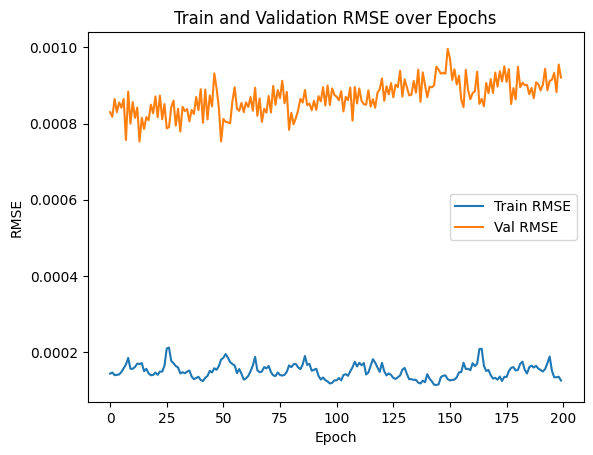

In [35]:

# Training and save the best model
import math
best_val = math.inf
EPOCHS = 200
file_save_best_model = "best_mlp.pt"

def run_epoch(loader, train=False):
    if train: model.train()
    else: model.eval()
    losses = []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb)
        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        losses.append(loss.item())
    return np.mean(losses)

train_loss = []
val_loss = []

for epoch in range(EPOCHS):
    train_loss.append(run_epoch(train_loader, train=True))
    val_loss.append(run_epoch(val_loader, train=False))
    if val_loss[-1] < best_val:
        best_val = val_loss[-1]
        best_model = model.state_dict()
        torch.save(best_model, file_save_best_model)
    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss[-1]:.6f} - Val Loss: {val_loss[-1]:.6f}")
        
best_model = torch.load(file_save_best_model)
model.load_state_dict(best_model)

plt.plot(range(EPOCHS), train_loss, label='Train RMSE')
plt.plot(range(EPOCHS), val_loss, label='Val RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Train and Validation RMSE over Epochs')
plt.legend()
plt.show()

### 4.2 Test evaluation

Now the MLP is trained, the objective is to evaluate the performance on a non trained dataset: the test set.

<span style="color: blue;">**4.4** Compute the RMSE, MAE and Directional Accuracy of the **best** trained MLP on the test set.</span>

<span style="color: blue;">**4.5** Plot the predicted $\hat{y}_t$ and the real $y_t$ on the same graph.</span>


MLP on Test Set: RMSE=0.000758 | MAE=0.019173 | Directional Acc=51.70%


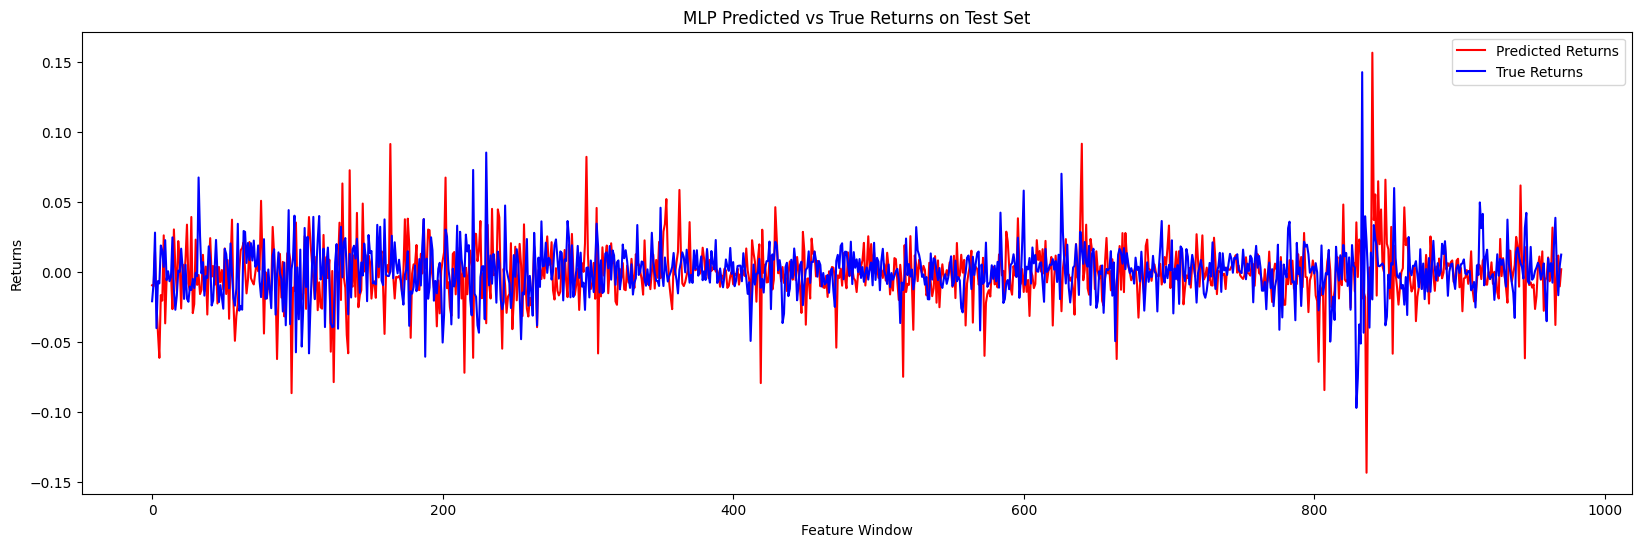

In [42]:
# Load the best model (saved during learning)
model.load_state_dict(torch.load(file_save_best_model, map_location=device))
model.eval()

# Prediction on the test set
with torch.no_grad():
    y_test_pred = []
    for xb, _ in test_loader:
        xb = xb.to(device)
        y_test_pred.append(model(xb).cpu().numpy())
    y_test_pred = np.concatenate(y_test_pred, axis=0).squeeze()

evaluate(y_test, y_test_pred, prefix="MLP on Test Set: ")

plt.figure(figsize=(20, 6))
plt.plot(y_test_pred, label='Predicted Returns', color='red')
plt.plot(y_test, label='True Returns', color='blue')
plt.xlabel('Feature Window')
plt.ylabel('Returns')
plt.title('MLP Predicted vs True Returns on Test Set')
plt.legend()
plt.show()

## 5. Avoid / limit overfitting

The act of saving the best model (according to the validation set !) allows us to limit the overfitting effect. 

Another way to regularize the problem is to force several neurons to ouput zero. Specifically, the option "Dropout" of nn.Module allows us to easily fix a given rate of neuron (radomly chosen at each step) to outpu zero.

<span style="color: blue;">**5.1** Modify the MLP class to add, for each layer, the Dropout option with rate 0.2 (i.e. 20% of neurons outputting zero) and rerun the learning and performance evaluation.</span>



**Nota**: by saving the best model, we can add a control variable that allows to stop the run if overfitting is observed. For this, we can introduce a control variable `patience_cn` that counts the number of successive runs where the performance in the validation test is not increased. If `patience_cnt` is above a limit `patience_threshold` (patience_threshold = 30, i.e. no better performance during 30 steps), the run is stopped. 

<span style="color: blue;">**5.2** Redo the training with the new (regularized) MLP and the early stopping option explained above.</span>

<span style="color: blue;">**5.3** Compute the RMSE, MAE and Directional Accuracy of the **best** trained MLP on the test set.</span>

<span style="color: blue;">**5.4** Plot the predicted $\hat{y}_t$ and the real $y_t$ on the same graph.</span>

<span style="color: blue;">**5.5** What do you conclude ?</span>


Epoch 1/200 - Train Loss: 0.016543 - Val Loss: 0.002025
Epoch 11/200 - Train Loss: 0.000765 - Val Loss: 0.000453
Epoch 21/200 - Train Loss: 0.000647 - Val Loss: 0.000446
Epoch 31/200 - Train Loss: 0.000603 - Val Loss: 0.000455
Epoch 41/200 - Train Loss: 0.000698 - Val Loss: 0.000433
Epoch 51/200 - Train Loss: 0.000591 - Val Loss: 0.000432
Early stopping at epoch 59


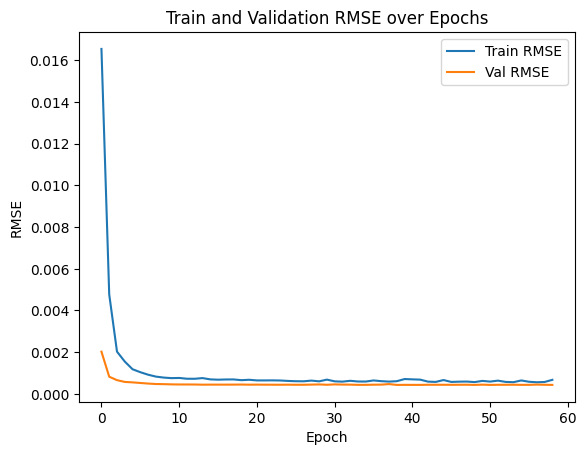

In [44]:
# Model: add nn.Dropout(alpha) step, with alpha = ratio of neurons desactivated
class MLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        return self.net(x).squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP(in_dim=X_train_s.shape[1]).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)


# Training with early stopping on validation RMSE
import math

best_val = math.inf
EPOCHS = 200
file_save_best_model = "best_mlp.pt"

train_loss = []
val_loss = []
patience = 20

for epoch in range(EPOCHS):
    train_loss.append(run_epoch(train_loader, train=True))
    val_loss.append(run_epoch(val_loader, train=False))
    
    if val_loss[-1] < best_val:
        best_val = val_loss[-1]
        torch.save(model.state_dict(), file_save_best_model)
        patience = 20
    else:
        patience -= 1
        if patience == 0:
            print(f"Early stopping at epoch {epoch+1}")
            EPOCHS = epoch + 1  # Update EPOCHS to the current epoch for plotting
            break
    
    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        print(
            f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss[-1]:.6f} - Val Loss: {val_loss[-1]:.6f}"
        )

best_model = torch.load(file_save_best_model)
model.load_state_dict(best_model)

plt.plot(range(EPOCHS), train_loss, label="Train RMSE")
plt.plot(range(EPOCHS), val_loss, label="Val RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Train and Validation RMSE over Epochs")
plt.legend()
plt.show()

## 6. Reflection / Improvements

**Questions**
- Did your NN beat the baselines significantly on RMSE or directional accuracy ?
- Why is forecasting noisy returns hard ?
- Is RMSE relevant for price prediction task ? Or any classical statistical loss ? 

**Improvements**
- Features of (short term, long term) tendency are often useful to improve prediction performance. For this, one can build moving averages of the most recent returns. For example :
- Moving Average (5 days): `df["ma_5"] = df["close"].rolling(5).mean()`
- Moving Aerage (20 days): `df["ma_20"] = df["close"].rolling(20).mean()`
- Exponentially Weighted Moving Average: `df["ema_10"] = df["close"].ewm(span=10, adjust=False).mean()`

The first two variables are averages of the last 5 (resp. 20) observed prices $$\text{ma}_N = \frac{1}{N}\sum_{k=0}^{N-1}P_{t-i}$$.

The last variable compute a classical exponentially weighted moving average, i.e creating the time series $$\text{ema}(t) = \alpha P_t + (1-\alpha)\text{ema}(t-1),$$ with $\alpha = \frac{2}{\text{span}+1}$. The parameter "span" corresponds to the average number of prices significantly taken into account in the averaging.

<span style="color: red;">**6.1** Add these variables into $X$ and rerun the MLP training and evaluation.</span>

New feature matrix shape: (6472, 23)
Epoch 1/200 - Train Loss: 0.003481 - Val Loss: 0.000605
Epoch 11/200 - Train Loss: 0.000690 - Val Loss: 0.000446
Epoch 21/200 - Train Loss: 0.000639 - Val Loss: 0.000431
Epoch 31/200 - Train Loss: 0.000614 - Val Loss: 0.000431
Early stopping at epoch 40

=== Results with Moving Average Features ===
MLP (with MA) on Test Set: RMSE=0.000335 | MAE=0.013090 | Directional Acc=47.58%


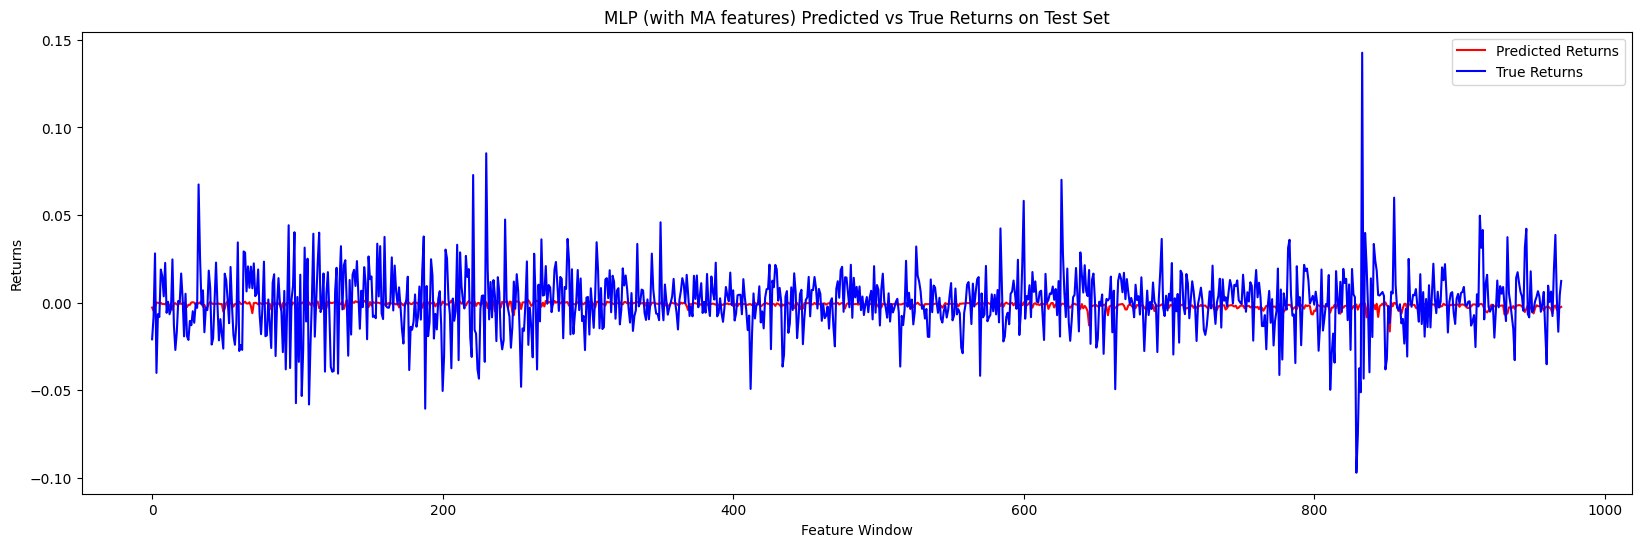

In [51]:
df["ma_5"] = df["close"].rolling(5).mean() # Moving Average :
df["ma_20"] = df["close"].rolling(20).mean() # Moving Average
df["ema_10"] = df["close"].ewm(span=10, adjust=False).mean()
df[["close","ret","target","ma_5","ma_20","ema_10"]].head()


ma5  = df["ma_5"].to_numpy()
ma20 = df["ma_20"].to_numpy()
ema10 = df["ema_10"].to_numpy()

# Variables at time t (one value per window)
ma5_t  = ma5[K-1:]    # shape (N,)
ma20_t = ma20[K-1:]   # shape (N,)
ema10_t = ema10[K-1:] # shape (N,)

# Stack these three columns onto X along the column axis (axis=1)
X_new = np.concatenate(
    [X,
     ma5_t[:, None],
     ma20_t[:, None],
     ema10_t[:, None]
    ],
    axis=1
)

# Evaluate the performance of the new model
print(f"New feature matrix shape: {X_new.shape}")

# Split the new data (time-aware)
(X_train_new, y_train_new), (X_val_new, y_val_new), (X_test_new, y_test_new) = time_split(X_new, y)

# Standardize the new data
scaler_new = StandardScaler()
X_train_new_s = scaler_new.fit_transform(X_train_new)
X_val_new_s   = scaler_new.transform(X_val_new)
X_test_new_s  = scaler_new.transform(X_test_new)

# Create new dataloaders
train_ds_new = TensorDataset(torch.tensor(X_train_new_s, dtype=torch.float32),
                             torch.tensor(y_train_new,   dtype=torch.float32))
val_ds_new   = TensorDataset(torch.tensor(X_val_new_s,   dtype=torch.float32),
                             torch.tensor(y_val_new,     dtype=torch.float32))
test_ds_new  = TensorDataset(torch.tensor(X_test_new_s,  dtype=torch.float32),
                             torch.tensor(y_test_new,    dtype=torch.float32))

train_loader_new = DataLoader(train_ds_new, batch_size=64, shuffle=False)
val_loader_new   = DataLoader(val_ds_new,   batch_size=256, shuffle=False)
test_loader_new  = DataLoader(test_ds_new,  batch_size=256, shuffle=False)

# Create new MLP with expanded input dimension
model_new = MLP(in_dim=X_train_new_s.shape[1]).to(device)
criterion_new = nn.MSELoss()
optimizer_new = torch.optim.Adam(model_new.parameters(), lr=0.003)

# Train the new model with early stopping
best_val_new = math.inf
EPOCHS_new = 200
file_save_best_model_new = "best_mlp_with_ma.pt"
patience = 20

train_loss_new = []
val_loss_new = []

for epoch in range(EPOCHS_new):
    # Training
    model_new.train()
    losses = []
    for xb, yb in train_loader_new:
        xb, yb = xb.to(device), yb.to(device)
        pred = model_new(xb)
        loss = criterion_new(pred, yb)
        optimizer_new.zero_grad()
        loss.backward()
        optimizer_new.step()
        losses.append(loss.item())
    train_loss_new.append(np.mean(losses))
    
    # Validation
    model_new.eval()
    losses = []
    with torch.no_grad():
        for xb, yb in val_loader_new:
            xb, yb = xb.to(device), yb.to(device)
            pred = model_new(xb)
            loss = criterion_new(pred, yb)
            losses.append(loss.item())
    val_loss_new.append(np.mean(losses))
    
    if val_loss_new[-1] < best_val_new:
        best_val_new = val_loss_new[-1]
        torch.save(model_new.state_dict(), file_save_best_model_new)
        patience = 20
    else:
        patience -= 1
        if patience == 0:
            print(f"Early stopping at epoch {epoch+1}")
            EPOCHS_new = epoch + 1
            break
    
    if epoch % 10 == 0 or epoch == EPOCHS_new - 1:
        print(f"Epoch {epoch+1}/{EPOCHS_new} - Train Loss: {train_loss_new[-1]:.6f} - Val Loss: {val_loss_new[-1]:.6f}")

# Load the best model
model_new.load_state_dict(torch.load(file_save_best_model_new, map_location=device))
model_new.eval()

# Prediction on the new test set
with torch.no_grad():
    y_test_new_pred = []
    for xb, _ in test_loader_new:
        xb = xb.to(device)
        y_test_new_pred.append(model_new(xb).cpu().numpy())
    y_test_new_pred = np.concatenate(y_test_new_pred, axis=0).squeeze()

print("\n=== Results with Moving Average Features ===")
evaluate(y_test_new, y_test_new_pred, prefix="MLP (with MA) on Test Set: ")

# Plot the results
plt.figure(figsize=(20, 6))
plt.plot(y_test_new_pred, label='Predicted Returns', color='red')
plt.plot(y_test_new, label='True Returns', color='blue')
plt.xlabel('Feature Window')
plt.ylabel('Returns')
plt.title('MLP (with MA features) Predicted vs True Returns on Test Set')
plt.legend()
plt.show()

## A.1 The Long Short Term Memory (LSTM) model
In this appendix, the objective is to build a LSTM model and compare the results to the previous ones.

Because LSTM is based on time memory, we must build batches such that memory is kept. Here, we propose to start from scratch and not use the previous loaders. 

In [ ]:
# Non.